# Reproduction Plan — Figures 1–2

## Setup

Coupled Rössler system with:

$$
\nu\in[-0.04,0.04],\qquad
\mu\in[0,0.12]
$$

Numerics:

- RK4, $h=0.01$
- sample every 20 steps
- $\Delta t=0.2$

---

## Figure 1 — Phase Synchronization Map

For each $(\nu,\mu)$:

1. Simulate coupled Rössler.
2. Compute mean frequencies $\Omega_x,\Omega_y$.
3. Calculate:

$$
|\Delta\Omega|=|\Omega_x-\Omega_y|
$$

4. Plot heatmap $|\Delta\Omega|(\nu,\mu)$.

### Expected

A clear **Arnold tongue** where:

$$
|\Delta\Omega|\approx0
$$

Meaning: this is the reference map of phase synchronization.

---

## Figure 2 — Joint $K_2$ Map

For the same $(\nu,\mu)$ grid:

$$
X,Y
\rightarrow
R^x,R^y
\rightarrow
JR
\rightarrow
P(l)
\rightarrow
\widehat K_2
$$

with:

$$
JR_{ij}=R^x_{ij}R^y_{ij}
$$

and:

$$
\ln P(l)\approx-K_2l\Delta t+C
$$

Plot:

$$
\widehat K_2(\nu,\mu)
$$

### Expected

- Structure broadly follows the Arnold tongue.
- Low-$K_2$ regions appear near synchronization boundaries.
- Ideally recover the characteristic low-$K_2$ "two-eyes" structure.

---

## Validation

Reproduction is successful if:

1. Figure 1 recovers the Arnold tongue.
2. Figure 2 shows corresponding joint-dynamics structure.
3. At selected parameter points:

$$
JR\rightarrow P(l)\rightarrow K_2
$$

behaves consistently.

> Target: **qualitative structural agreement**, not pixel-perfect reproduction.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# LOCAL IMPORTS
# =============================================================================

sys.path.append(os.path.abspath(".."))

from core_ntsa.multivariate_rp import (
    # 1. Independent Phase Space
    embed_time_series,
    align_embedded_trajectories,

    # 2. Independent Geometry
    compute_auto_distance_matrix,
    find_threshold_for_rr,
    compute_recurrence_matrix,

    # 3. Joint Recurrence
    compute_joint_recurrence_matrix,

    # 4. Joint Diagonal Statistics
    extract_all_diagonal_lengths,
    compute_diagonal_probability,

    # 5. Invariant Estimation
    estimate_k2_entropy,

    # 6. Result & Core Wrapper
    MRPResult,
    run_mrp_analysis,

    # 7. Historical Automation
    identify_scaling_region,
    identify_k2_plateau,
    analyze_automated_k2_vs_rr,
)

# =============================================================================
# REPRODUCIBILITY
# =============================================================================

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# =============================================================================
# NUMERICAL PARAMETERS — ROMANO ET AL. (2004)
# =============================================================================

H = 0.01
SAMPLE_EVERY = 20
DELTA_T = H * SAMPLE_EVERY       # 0.2

NU_MIN = -0.04
NU_MAX = 0.04

MU_MIN = 0.00
MU_MAX = 0.12

# Grid resolution will be defined later after single-point validation.

# =============================================================================
# PUBLICATION-QUALITY PLOT CONFIG
# =============================================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.figsize": (10, 6),
    "axes.grid": False,
})

In [2]:
# =============================================================================
# CELL 2 — COUPLED RÖSSLER SYSTEM
# =============================================================================

def coupled_rossler_rhs(state: np.ndarray, nu: float, mu: float) -> np.ndarray:
    """6D bidirectionally coupled Rössler system."""

    x1, x2, x3, y1, y2, y3 = state

    dx1 = -(1.0 + nu) * x2 - x3 + mu * (y1 - x1)
    dx2 = (1.0 + nu) * x1 + 0.15 * x2
    dx3 = 0.2 + x3 * (x1 - 10.0)

    dy1 = -(1.0 - nu) * y2 - y3 + mu * (x1 - y1)
    dy2 = (1.0 - nu) * y1 + 0.15 * y2
    dy3 = 0.2 + y3 * (y1 - 10.0)

    return np.array(
        [dx1, dx2, dx3, dy1, dy2, dy3],
        dtype=np.float64,
    )

In [3]:
# =============================================================================
# CELL 3 — NUMERICAL SIMULATION
# =============================================================================

def rk4_step(
    state: np.ndarray,
    h: float,
    nu: float,
    mu: float,
) -> np.ndarray:
    """One fixed-step RK4 update."""

    k1 = coupled_rossler_rhs(state, nu, mu)
    k2 = coupled_rossler_rhs(state + 0.5 * h * k1, nu, mu)
    k3 = coupled_rossler_rhs(state + 0.5 * h * k2, nu, mu)
    k4 = coupled_rossler_rhs(state + h * k3, nu, mu)

    return state + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def simulate_coupled_rossler(
    nu: float,
    mu: float,
    n_samples: int = 10_000,
    transient_samples: int = 2_000,
    h: float = H,
    sample_every: int = SAMPLE_EVERY,
    initial_state: np.ndarray = None,
):
    """
    Simulate coupled Rössler oscillators with fixed-step RK4.

    Returns
    -------
    t : (n_samples,) ndarray
        Sampled time axis.
    X : (n_samples, 3) ndarray
        Trajectory of subsystem X.
    Y : (n_samples, 3) ndarray
        Trajectory of subsystem Y.
    """

    if n_samples < 1:
        raise ValueError("n_samples must be >= 1.")

    if transient_samples < 0:
        raise ValueError("transient_samples must be >= 0.")

    if h <= 0:
        raise ValueError("h must be positive.")

    if sample_every < 1:
        raise ValueError("sample_every must be >= 1.")

    if initial_state is None:
        state = np.array(
            [1.0, 0.0, 0.0, -1.0, 0.0, 0.0],
            dtype=np.float64,
        )
    else:
        state = np.asarray(initial_state, dtype=np.float64).copy()

    total_samples = transient_samples + n_samples
    total_steps = total_samples * sample_every

    sampled = np.empty((total_samples, 6), dtype=np.float64)

    sample_idx = 0

    for step in range(total_steps):
        state = rk4_step(state, h, nu, mu)

        if (step + 1) % sample_every == 0:
            sampled[sample_idx] = state
            sample_idx += 1

    sampled = sampled[transient_samples:]

    X = sampled[:, :3]
    Y = sampled[:, 3:]

    delta_t = h * sample_every
    t = np.arange(n_samples, dtype=np.float64) * delta_t

    return t, X, Y

X finite: True
Y finite: True
X range:
[-1.44509166e+01 -1.62844745e+01  8.18396142e-03]
[16.75684122 13.09415306 27.13834245]
Y range:
[-1.43983234e+01 -1.63641529e+01  8.19025013e-03]
[17.02010946 12.92052976 29.54487969]


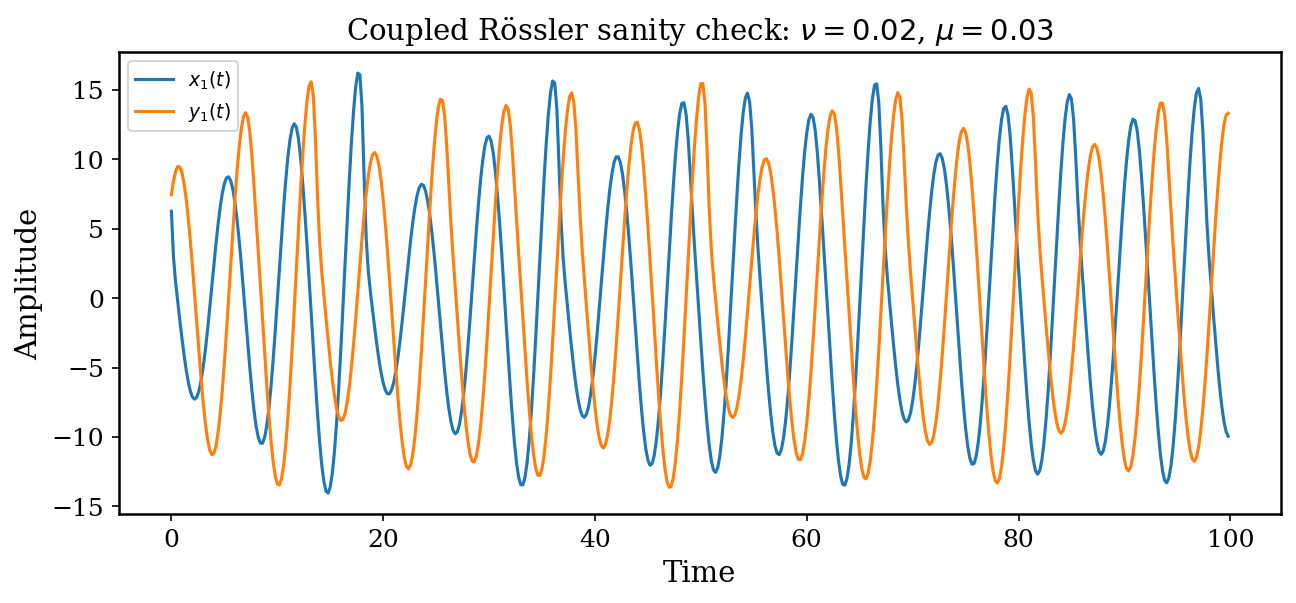

In [4]:
# =============================================================================
# CELL 4 — SIMULATION SANITY CHECK
# =============================================================================

NU_TEST = 0.02
MU_TEST = 0.03

t_test, X_test, Y_test = simulate_coupled_rossler(
    nu=NU_TEST,
    mu=MU_TEST,
    n_samples=5_000,
    transient_samples=2_000,
)

print("X finite:", np.all(np.isfinite(X_test)))
print("Y finite:", np.all(np.isfinite(Y_test)))

print("X range:")
print(np.min(X_test, axis=0))
print(np.max(X_test, axis=0))

print("Y range:")
print(np.min(Y_test, axis=0))
print(np.max(Y_test, axis=0))

# Short segment for visual inspection
n_plot = 500

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    t_test[:n_plot],
    X_test[:n_plot, 0],
    label=r"$x_1(t)$",
)

ax.plot(
    t_test[:n_plot],
    Y_test[:n_plot, 0],
    label=r"$y_1(t)$",
)

ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")
ax.set_title(
    rf"Coupled Rössler sanity check: $\nu={NU_TEST}$, $\mu={MU_TEST}$"
)
ax.legend()

plt.show()

In [5]:
# =============================================================================
# CELL 5 — MEAN FREQUENCY ESTIMATION
# =============================================================================

def estimate_mean_frequency(
    trajectory: np.ndarray,
    delta_t: float = DELTA_T,
) -> float:
    """Estimate mean angular frequency from a 3D Rössler trajectory."""

    x1 = trajectory[:, 0]
    x2 = trajectory[:, 1]

    phase = np.unwrap(np.arctan2(x2, x1))

    total_time = (len(phase) - 1) * delta_t

    if total_time <= 0:
        raise ValueError("Trajectory must contain at least two samples.")

    omega = (phase[-1] - phase[0]) / total_time

    return float(abs(omega))


def compute_frequency_difference(
    X: np.ndarray,
    Y: np.ndarray,
    delta_t: float = DELTA_T,
):
    """Compute |Omega_x - Omega_y|."""

    omega_x = estimate_mean_frequency(X, delta_t)
    omega_y = estimate_mean_frequency(Y, delta_t)

    delta_omega = abs(omega_x - omega_y)

    return omega_x, omega_y, float(delta_omega)

mu=0.000 | Omega_x=1.05690 | Omega_y=1.00677 | |Delta Omega|=0.050127
mu=0.010 | Omega_x=1.05280 | Omega_y=1.01186 | |Delta Omega|=0.040943
mu=0.020 | Omega_x=1.04644 | Omega_y=1.01129 | |Delta Omega|=0.035156
mu=0.030 | Omega_x=1.03904 | Omega_y=1.01260 | |Delta Omega|=0.026443
mu=0.040 | Omega_x=1.02442 | Omega_y=1.02459 | |Delta Omega|=0.000167
mu=0.060 | Omega_x=1.02907 | Omega_y=1.02938 | |Delta Omega|=0.000308
mu=0.080 | Omega_x=1.03156 | Omega_y=1.03154 | |Delta Omega|=0.000016


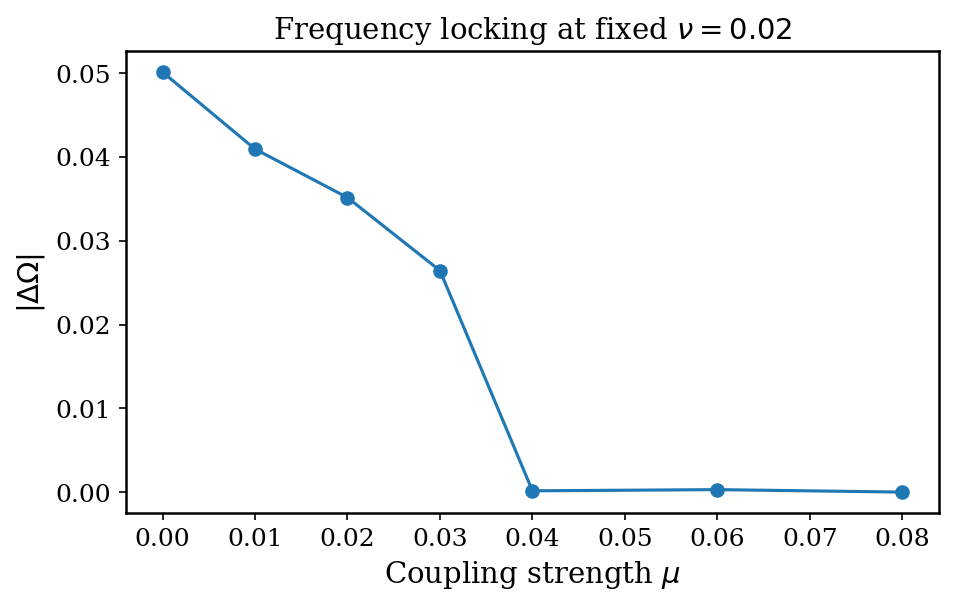

In [6]:
# =============================================================================
# CELL 6 — SINGLE-POINT SYNCHRONIZATION CHECK
# =============================================================================

NU_CHECK = 0.02

mu_check_values = np.array([
    0.00,
    0.01,
    0.02,
    0.03,
    0.04,
    0.06,
    0.08,
])

delta_omega_check = []

for mu in mu_check_values:

    _, X, Y = simulate_coupled_rossler(
        nu=NU_CHECK,
        mu=mu,
        n_samples=5_000,
        transient_samples=2_000,
    )

    omega_x, omega_y, delta_omega = compute_frequency_difference(
        X,
        Y,
    )

    delta_omega_check.append(delta_omega)

    print(
        f"mu={mu:.3f} | "
        f"Omega_x={omega_x:.5f} | "
        f"Omega_y={omega_y:.5f} | "
        f"|Delta Omega|={delta_omega:.6f}"
    )

delta_omega_check = np.asarray(delta_omega_check)


fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    mu_check_values,
    delta_omega_check,
    marker="o",
)

ax.set_xlabel(r"Coupling strength $\mu$")
ax.set_ylabel(r"$|\Delta\Omega|$")
ax.set_title(
    rf"Frequency locking at fixed $\nu={NU_CHECK}$"
)

plt.show()

In [7]:
# =============================================================================
# CELL 7 — FIGURE 1 PARAMETER SWEEP
# =============================================================================

# Moderate grid for first reproduction.
NU_VALUES = np.linspace(NU_MIN, NU_MAX, 41)
MU_VALUES = np.linspace(MU_MIN, MU_MAX, 61)

delta_omega_map = np.empty(
    (len(MU_VALUES), len(NU_VALUES)),
    dtype=np.float64,
)

N_SAMPLES_FIG1 = 5_000
TRANSIENT_SAMPLES_FIG1 = 2_000


for i_mu, mu in enumerate(MU_VALUES):

    for i_nu, nu in enumerate(NU_VALUES):

        _, X, Y = simulate_coupled_rossler(
            nu=nu,
            mu=mu,
            n_samples=N_SAMPLES_FIG1,
            transient_samples=TRANSIENT_SAMPLES_FIG1,
        )

        _, _, delta_omega = compute_frequency_difference(
            X,
            Y,
        )

        delta_omega_map[i_mu, i_nu] = delta_omega

    print(
        f"Completed mu {i_mu + 1:02d}/{len(MU_VALUES)} "
        f"({mu:.4f})"
    )

Completed mu 01/61 (0.0000)
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/vutu0809/Desktop/NTSA_Foundation/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_22936/2210354997.py", line 22, in <module>
    _, X, Y = simulate_coupled_rossler(
              ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_22936/1619509250.py", line None, in simulate_coupled_rossler
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/vutu0809/Desktop/NTSA_Foundation/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 2105, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vutu0809/Desktop/NTSA_Foundation/.venv/lib/python3.11/site-packages/IPython/core/ultratb.py", line 1396, in structured_traceback
    return FormattedTB.struc

In [ ]:
# =============================================================================
# CELL 8 — PLOT FIGURE 1
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

mesh = ax.pcolormesh(
    NU_VALUES,
    MU_VALUES,
    delta_omega_map,
    shading="auto",
)

cbar = fig.colorbar(mesh, ax=ax)

cbar.set_label(
    r"$|\Delta\Omega|$"
)

ax.set_xlabel(
    r"Frequency mismatch $\nu$"
)

ax.set_ylabel(
    r"Coupling strength $\mu$"
)

ax.set_title(
    r"Phase Synchronization Map — $|\Delta\Omega|$"
)

plt.show()